In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
stock=pd.read_csv("stock_cleaned.csv")

In [3]:
# Basic stats
print(stock.describe())

              open         high          low        close        volume  \
count  2088.000000  2088.000000  2088.000000  2088.000000  2.088000e+03   
mean    978.758779   990.041978   967.707869   482.344962  4.242781e+07   
std    1317.482877  1330.590945  1304.697939   446.499424  2.158829e+07   
min      49.120000    52.660000    43.720000     1.000000  1.000000e+03   
25%     147.072500   149.635000   144.542500   147.437500  2.422927e+07   
50%     262.250000   265.140000   259.815000   257.315000  4.266100e+07   
75%    1060.067500  1078.977500  1052.072500   582.257500  6.021920e+07   
max    4304.310000  4372.480000  4282.330000  1237.600000  1.142109e+08   

       daily_return_pct   pct_change         ma_7        ma_30        ma_50  \
count       2088.000000  2088.000000  2088.000000  2088.000000  2088.000000   
mean           0.009543     0.010804   482.907314   975.855738   972.071858   
std            1.892486     2.003130   446.273050  1310.184837  1302.794316   
min     

In [4]:
print(stock['signal'].value_counts())

signal
Buy     1011
Sell     959
Hold     118
Name: count, dtype: int64


In [5]:
print(stock['ticker'].value_counts())

ticker
GOOGL    261
JNJ      261
JPM      261
AMZN     261
TSLA     261
AAPL     261
NFLX     261
MSFT     261
Name: count, dtype: int64


In [6]:
print(stock['sector'].value_counts())

sector
Technology       783
Healthcare       261
Finance          261
E-Commerce       261
Automotive       261
Entertainment    261
Name: count, dtype: int64


In [7]:
print(stock.nunique())

ticker                 8
sector                 6
date                 261
open                2033
high                2020
low                 2024
close               1493
volume              2043
daily_return_pct    1916
pct_change          1919
ma_7                1485
ma_30               2010
ma_50               1999
rsi                 1587
macd                1168
volatility_10d      1790
signal                 3
next_day_return     1871
dtype: int64


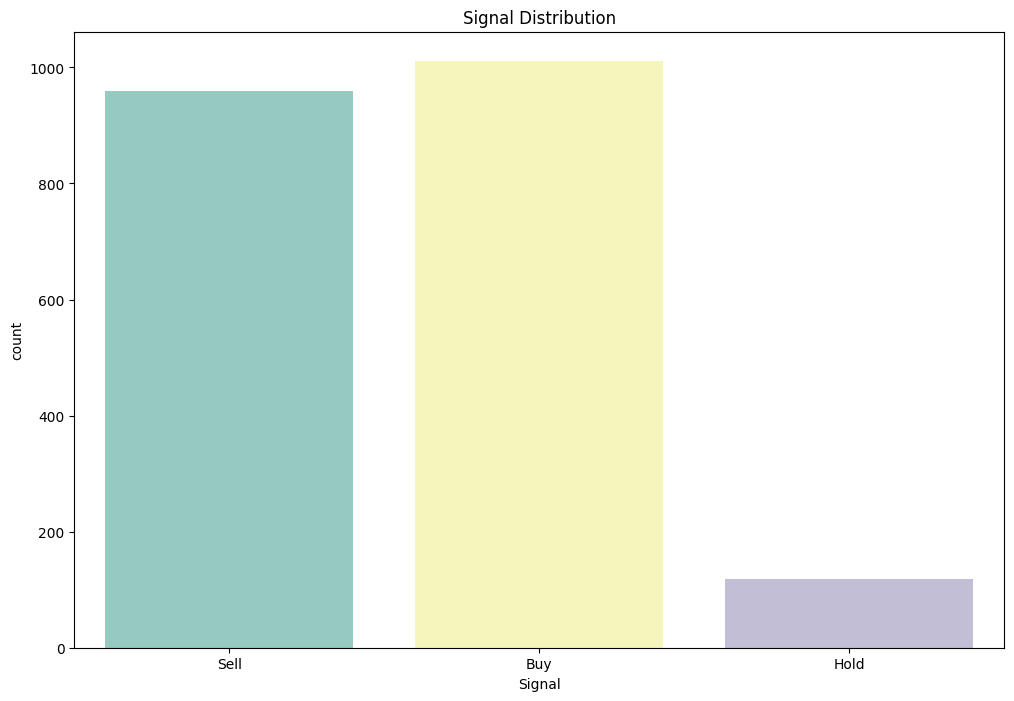

In [8]:
plt.figure(figsize=(12,8))
sns.countplot(x=stock["signal"],palette="Set3",hue=stock["signal"],legend=False)
plt.title("Signal Distribution")
plt.xlabel("Signal")
plt.show()

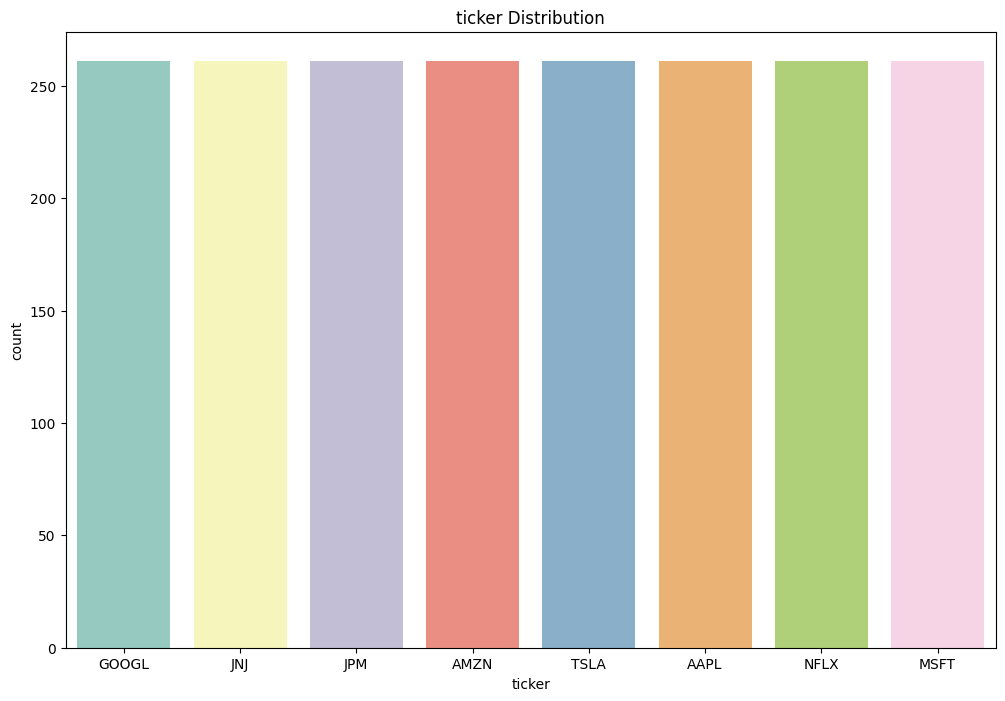

In [9]:
plt.figure(figsize=(12,8))
sns.countplot(x=stock["ticker"],palette="Set3",hue=stock["ticker"],legend=False)
plt.title("ticker Distribution")
plt.xlabel("ticker")
plt.show()

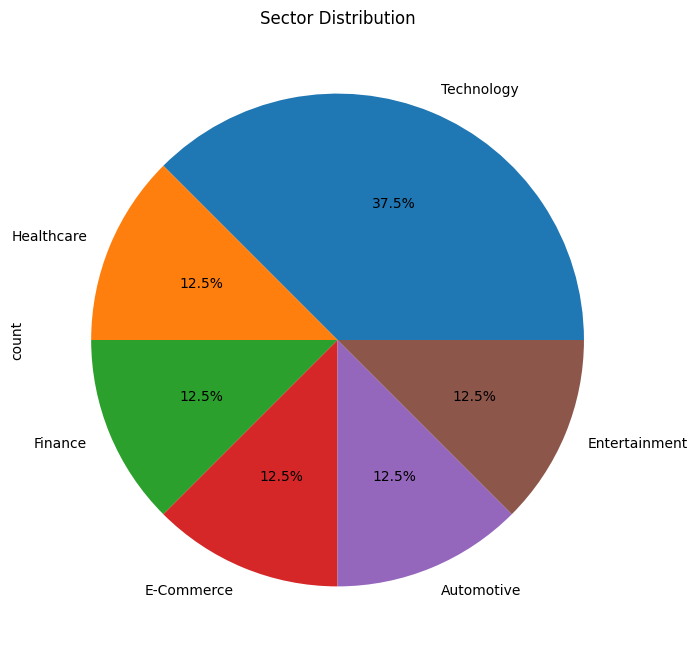

In [10]:
plt.figure(figsize=(8,8))
stock["sector"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
    
)
plt.title('Sector Distribution')
plt.show()

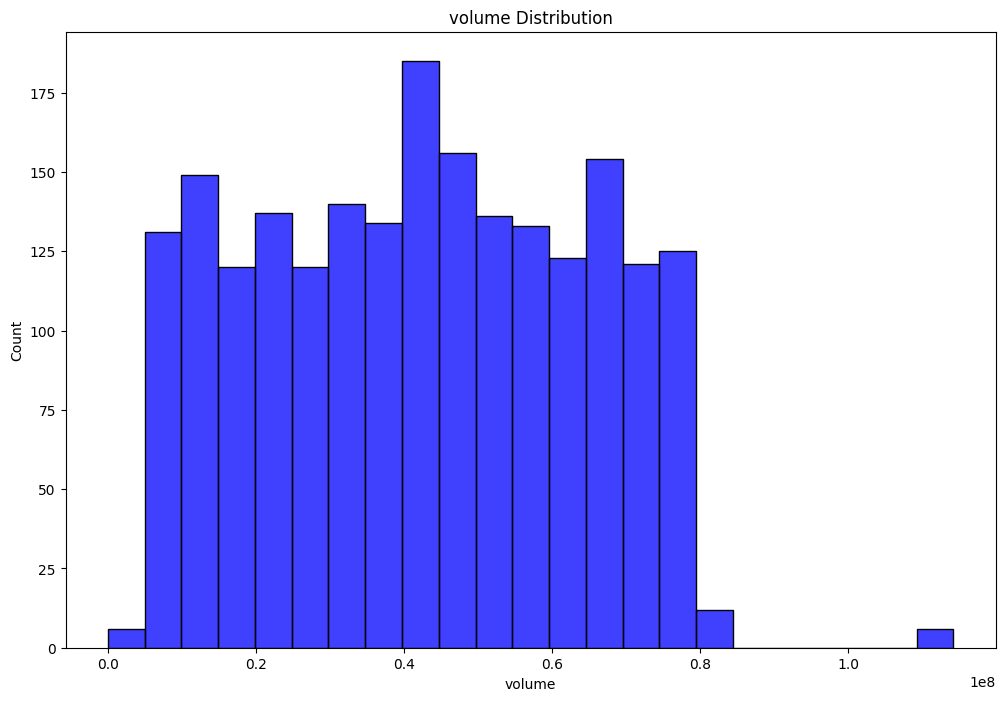

In [11]:
plt.figure(figsize=(12,8))

sns.histplot(stock["volume"],color="blue",bins=23)
plt.title("volume Distribution")
plt.xlabel("volume")
plt.show()

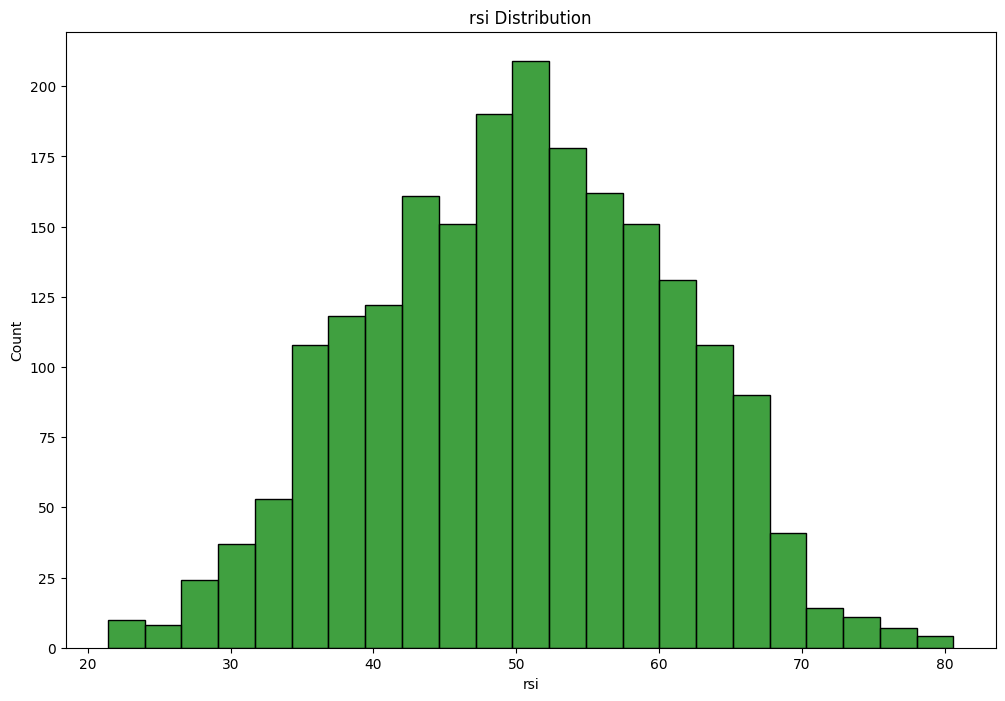

In [12]:
plt.figure(figsize=(12,8))

sns.histplot(stock["rsi"],color="green",bins=23)
plt.title("rsi Distribution")
plt.xlabel("rsi")
plt.show()

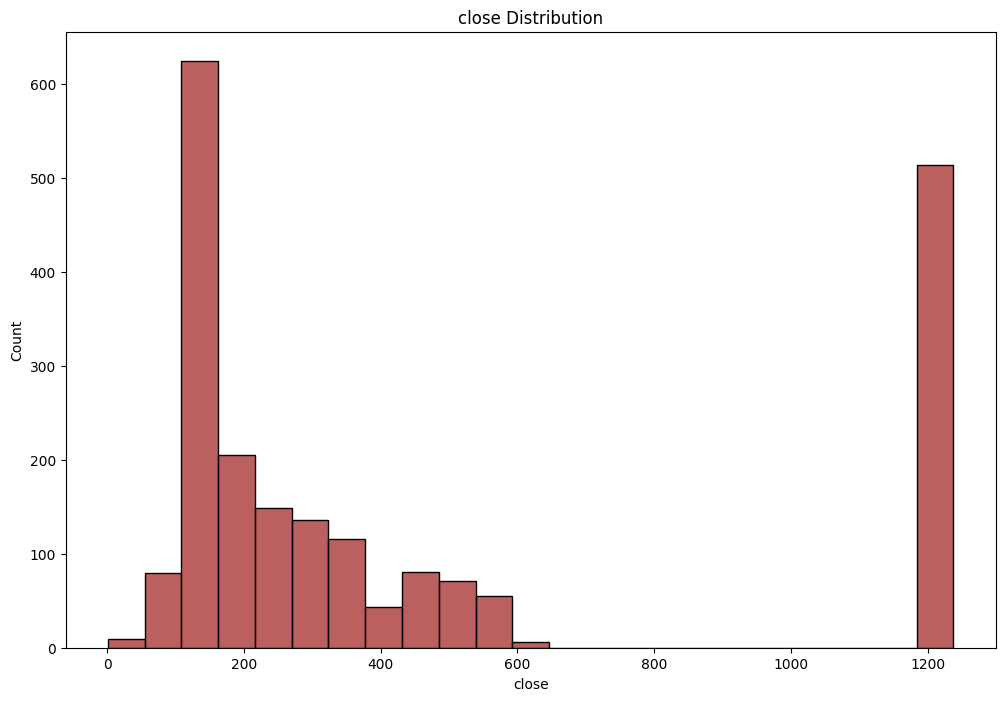

In [13]:
plt.figure(figsize=(12,8))

sns.histplot(stock["close"],color="brown",bins=23)
plt.title("close Distribution")
plt.xlabel("close")
plt.show()

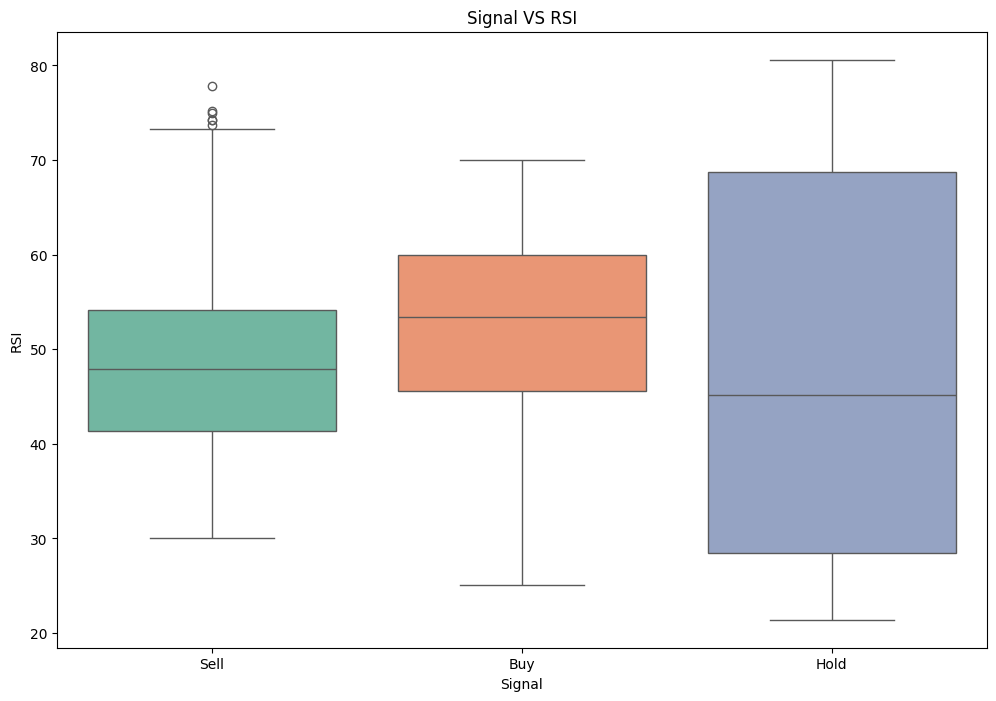

In [14]:
plt.figure(figsize=(12,8))
sns.boxplot(
    x=stock['signal'],
    y=stock['rsi'],
    hue=stock['signal'],
    palette='Set2',
    legend=False
)
plt.title('Signal VS RSI')
plt.xlabel('Signal')
plt.ylabel('RSI')
plt.show()


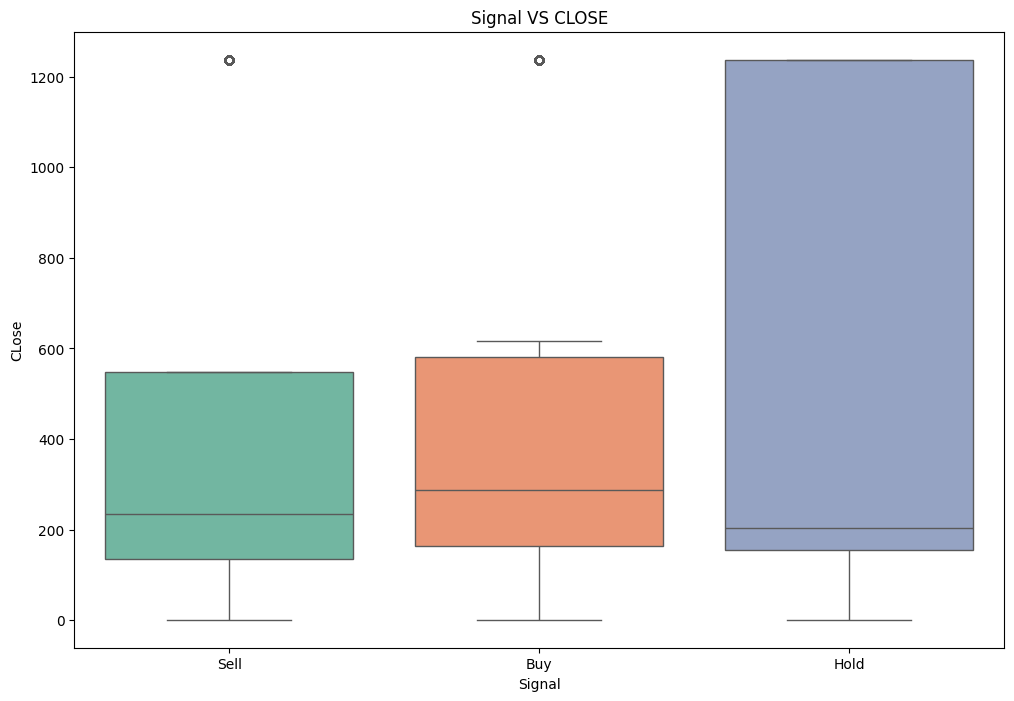

In [15]:
plt.figure(figsize=(12,8))
sns.boxplot(
    x=stock['signal'],
    y=stock['close'],
    hue=stock['signal'],
    palette='Set2',
    legend=False
)
plt.title('Signal VS CLOSE')
plt.xlabel('Signal')
plt.ylabel('CLose')
plt.show()


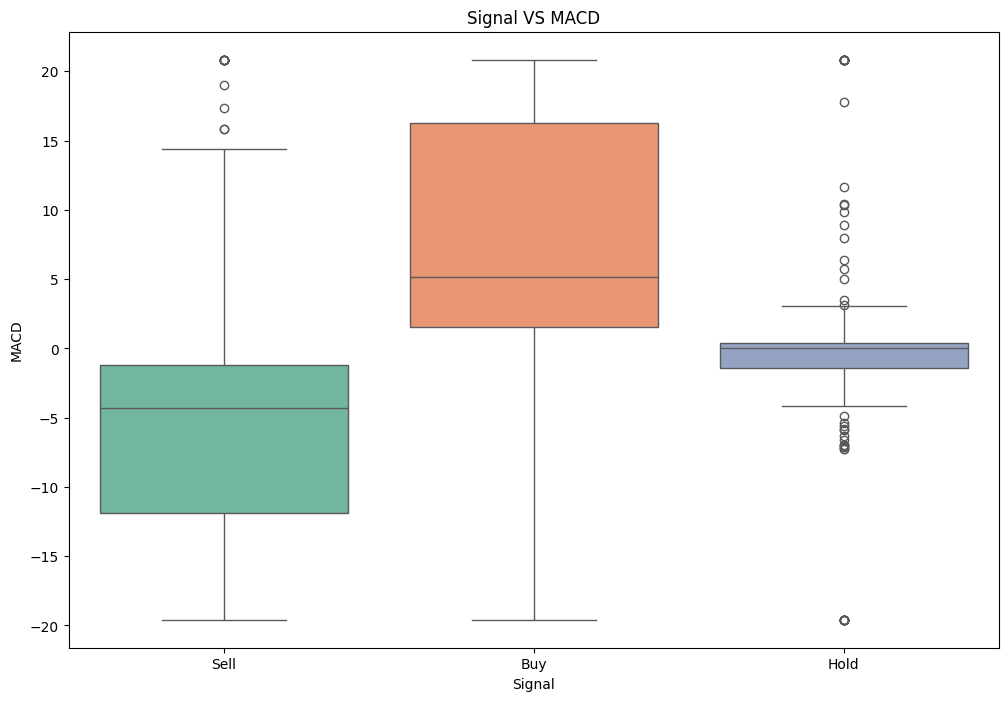

In [16]:
plt.figure(figsize=(12,8))
sns.boxplot(
    x=stock['signal'],
    y=stock['macd'],
    hue=stock['signal'],
    palette='Set2',
    legend=False
)
plt.title('Signal VS MACD')
plt.xlabel('Signal')
plt.ylabel('MACD')
plt.show()


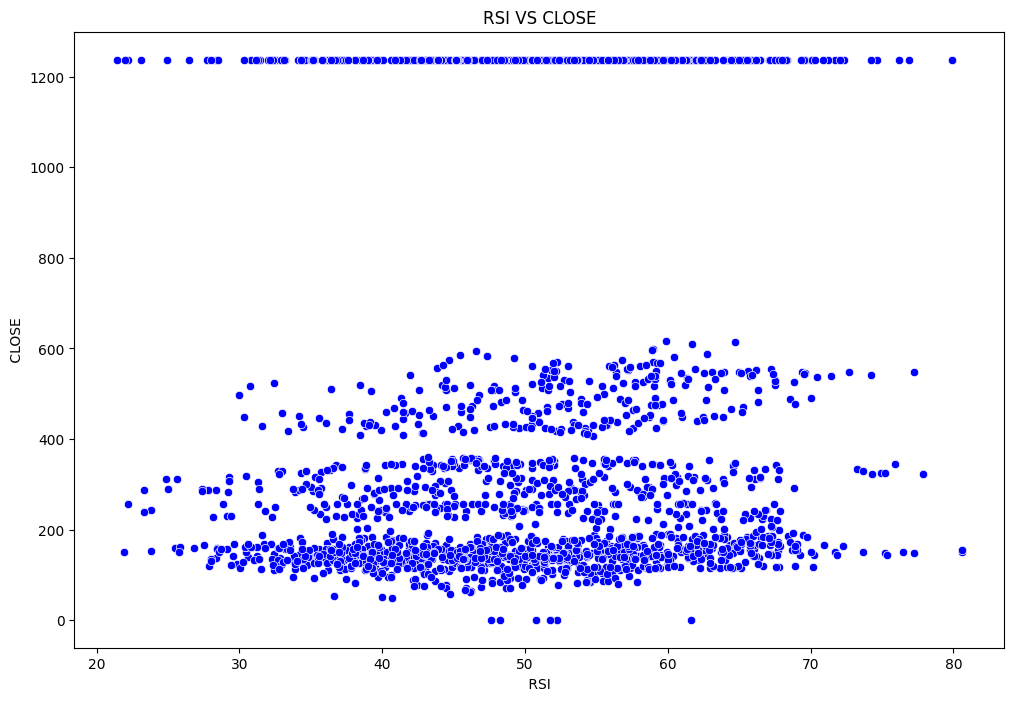

In [17]:
plt.figure(figsize=(12,8))
sns.scatterplot(
    x=stock['rsi'],
    y=stock['close'],
    color='blue'
)
plt.title('RSI VS CLOSE')
plt.xlabel(' RSI ')
plt.ylabel(' CLOSE ')
plt.show()

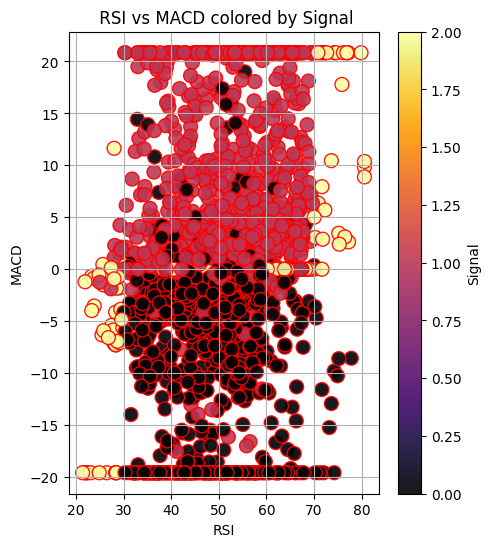

In [18]:
stock["signal"]=stock["signal"].map({
   'Sell':0,
    'Buy':1, 
    'Hold':2
})
plt.figure(figsize=(5,6))
scatter1=plt.scatter(
    stock["rsi"],
    stock["macd"],
    c=stock["signal"],
    cmap="inferno",
    s=100,
    alpha=0.9,
    edgecolors="red"
)
plt.title(" RSI vs MACD colored by Signal")
plt.xlabel("RSI")
plt.ylabel("MACD")
cbar=plt.colorbar(scatter1)
cbar.set_label("Signal")
plt.grid(True)
plt.show()

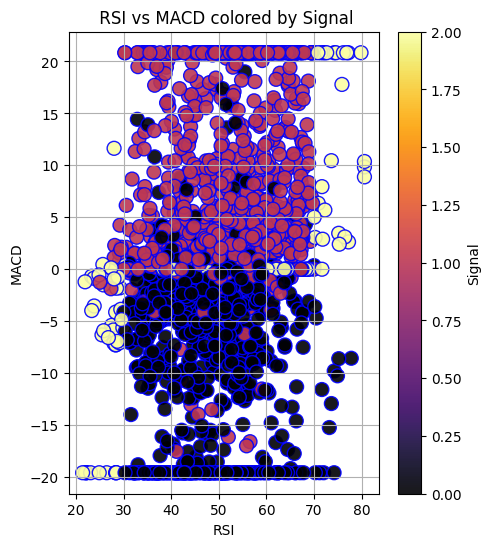

In [19]:

plt.figure(figsize=(5,6))
scatter1=plt.scatter(
    stock["rsi"],
    stock["macd"],
    c=stock["signal"],
    cmap="inferno",
    s=100,
    alpha=0.9,
    edgecolors="blue"
)
plt.title(" RSI vs MACD colored by Signal")
plt.xlabel("RSI")
plt.ylabel("MACD")
cbar=plt.colorbar(scatter1)
cbar.set_label("Signal")
plt.grid(True)
plt.show()

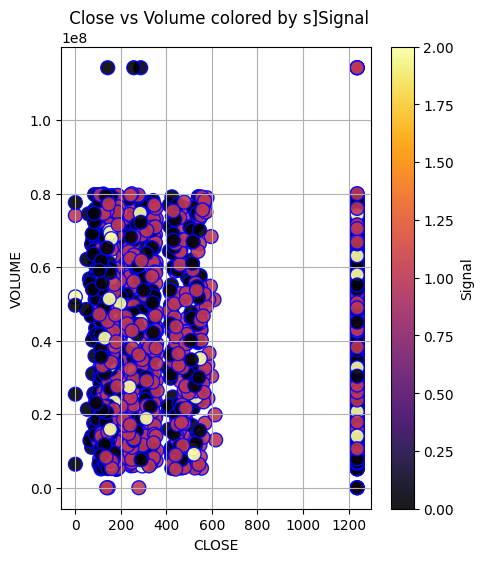

In [20]:

plt.figure(figsize=(5,6))
scatter1=plt.scatter(
    stock["close"],
    stock["volume"],
    c=stock["signal"],
    cmap="inferno",
    s=100,
    alpha=0.9,
    edgecolors="blue"
)
plt.title(" Close vs Volume colored by s]Signal")
plt.xlabel("CLOSE")
plt.ylabel("VOLUME")
cbar=plt.colorbar(scatter1)
cbar.set_label("Signal")
plt.grid(True)
plt.show()




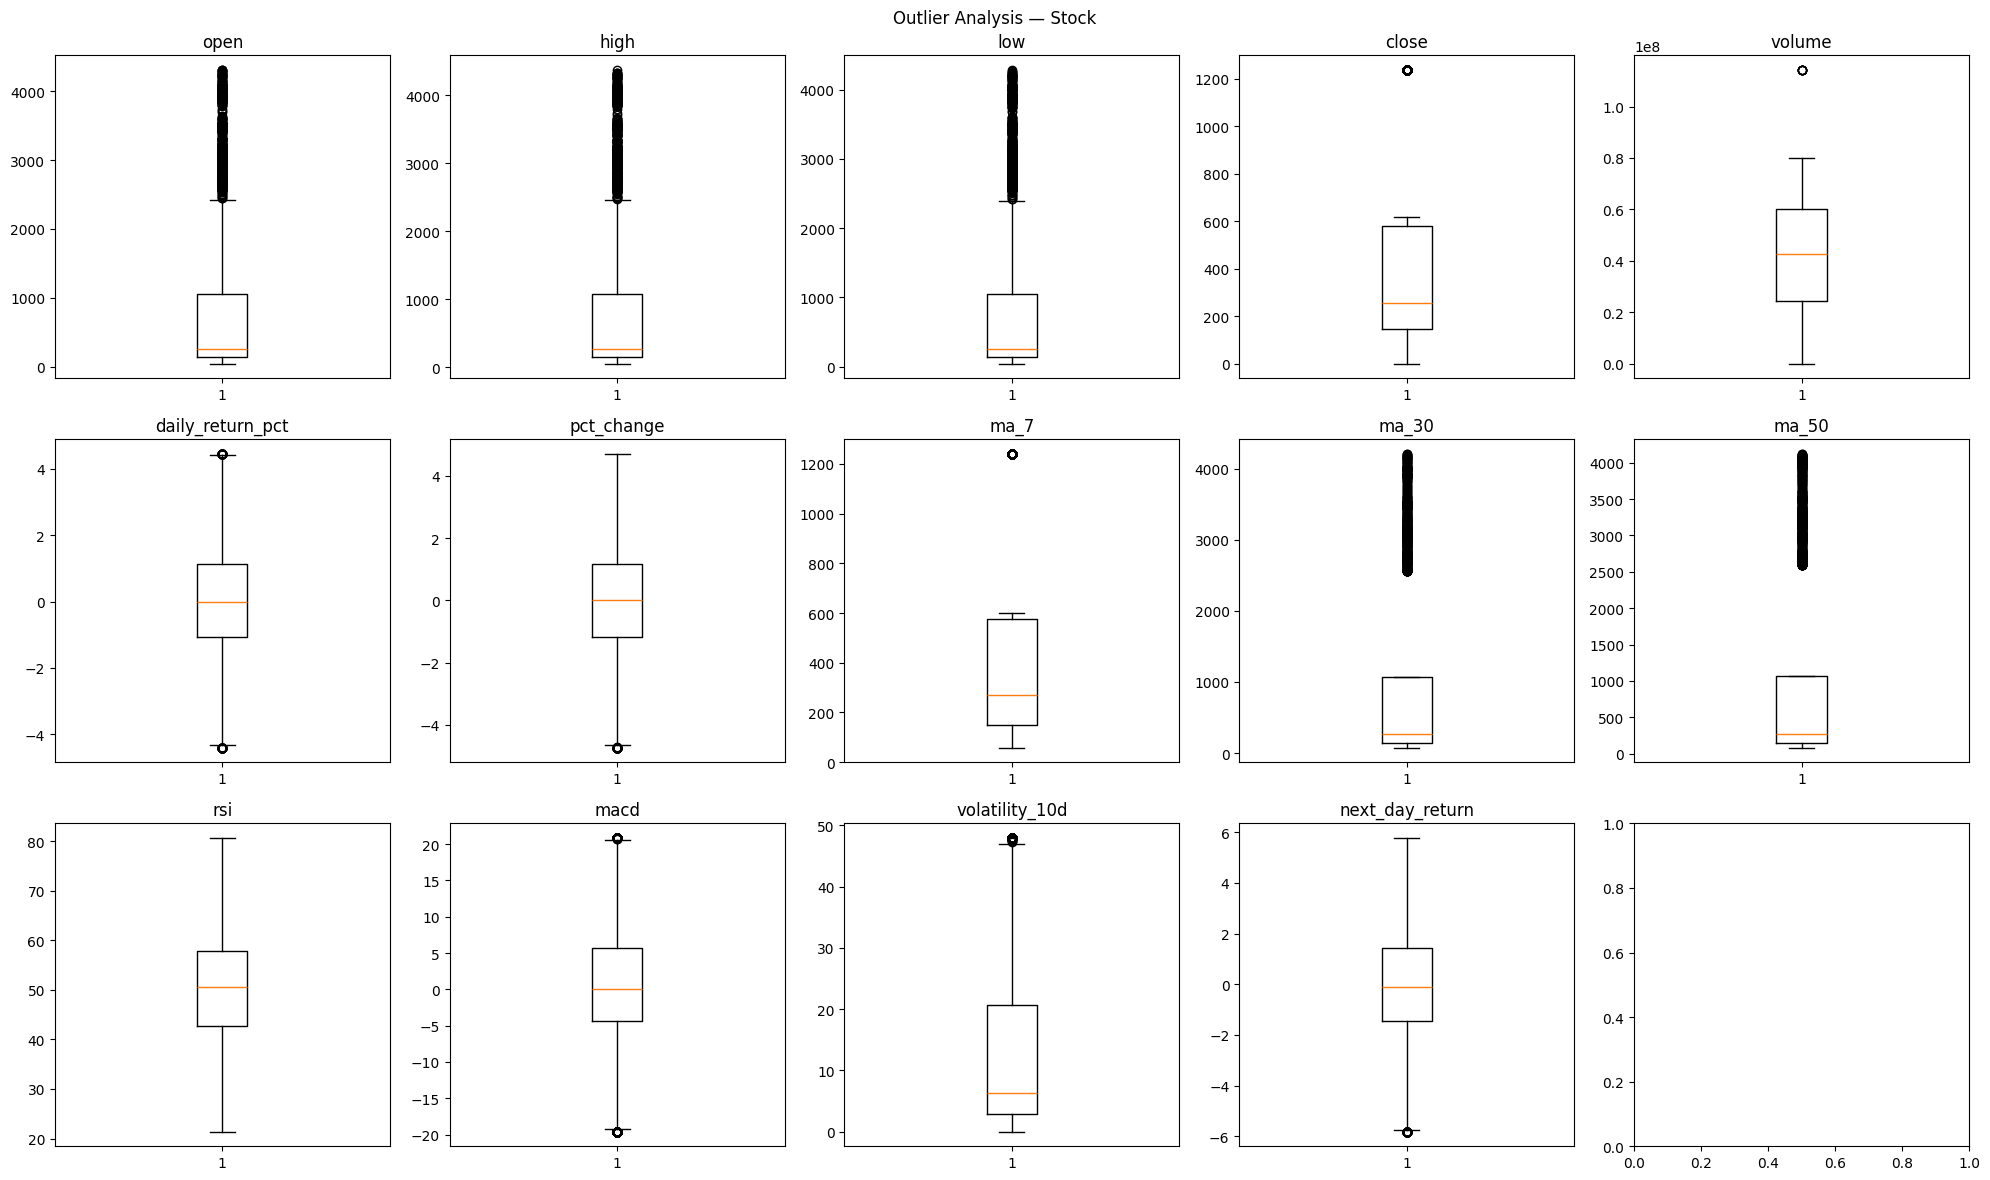

In [21]:
fig,axes=plt.subplots(3,5,figsize=(20,12))
cols=['open', 'high', 'low', 'close', 
        'volume', 'daily_return_pct', 'pct_change', 
        'ma_7', 'ma_30', 'ma_50', 'rsi',
        'macd', 'volatility_10d', 'next_day_return']

for i , col in enumerate(cols):
    ax=axes[i//5][i%5]
    ax.boxplot(stock[col].dropna())
    ax.set_title(col)

plt.suptitle('Outlier Analysis — Stock')
plt.tight_layout()
plt.show()

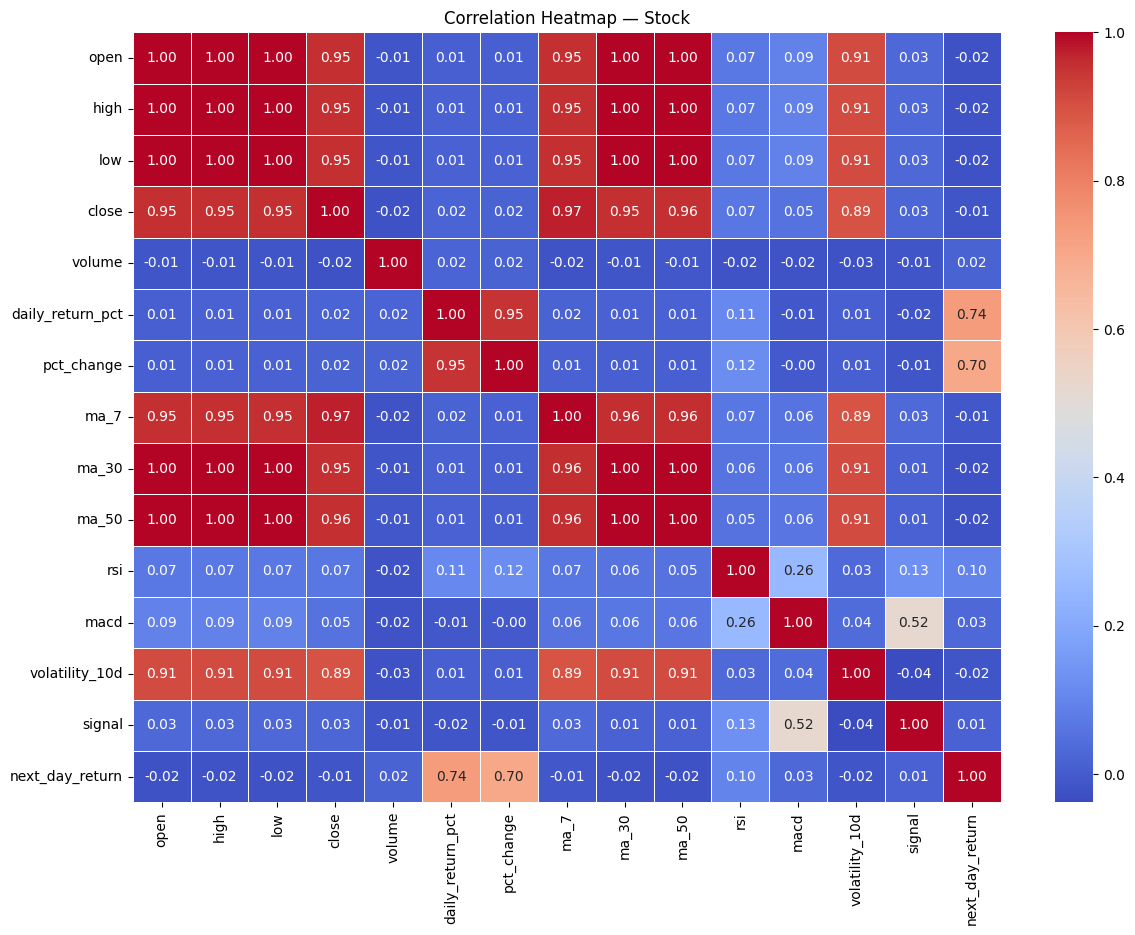

In [22]:
plt.figure(figsize=(14,10))
sns.heatmap(
    stock.corr(numeric_only=True),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Correlation Heatmap — Stock')
plt.show()

In [23]:
'''
1. MACD is strongest predictor of Buy/Sell/Hold (0.52)
2. Open, High, Low prices are perfectly correlated (1.00)
3. High priced stocks are more volatile (0.91)
4. Today's return predicts tomorrow's return (0.74)
5. Volume has no relationship with price
6. RSI and MACD together determine signal
7. AAPL MACD crosses 0 multiple times in 2021
'''

"\n1. MACD is strongest predictor of Buy/Sell/Hold (0.52)\n2. Open, High, Low prices are perfectly correlated (1.00)\n3. High priced stocks are more volatile (0.91)\n4. Today's return predicts tomorrow's return (0.74)\n5. Volume has no relationship with price\n6. RSI and MACD together determine signal\n7. AAPL MACD crosses 0 multiple times in 2021\n"